In [1]:
#START WITH 64GB memory
!pip install ~/oceanmodes/

Processing /home/jovyan/oceanmodes
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for oceanmodes: filename=oceanmodes-0.1-py3-none-any.whl size=7998 sha256=7486f2f52a43f6869a52893a88ac2f3b0db2290b0b413ac5f45bd9a9da01264c
  Stored in directory: /tmp/pip-ephem-wheel-cache-nfycay3a/wheels/87/29/b1/27b4148e3fb2c1e2555fde3db65e657a1e7a8e2d43b40a0d9d
Successfully built oceanmodes
  Attempting uninstall: oceanmodes
    Found existing installation: oceanmodes 0.1
    Uninstalling oceanmodes-0.1:
      Successfully uninstalled oceanmodes-0.1


In [2]:
import xrft
import xarray as xr
from xgcm.grid import Grid
import xgcm
import matplotlib as mpl
from xhistogram.xarray import histogram
from typing import Annotated
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from oceanmodes import baroclinic

In [4]:
dens = xr.open_dataset('/home/jovyan/llc-hero-calc/analysis/posters/dens_gs.nc')

In [5]:
N2 = -9.81 *dens['density']/dens['Z'].diff('k')/1025
fm = 2*2*np.pi/24/3600*np.sin(35*np.pi/180)
zphi, RdS, vdS = baroclinic.neutral_modes_from_N2_profile(-dens['Z'].values[2:], N2.values[1:], fm,num_eigen=11,init_vector=None,num_Lanczos=None,iteration=None,tolerance=0)

In [6]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC','XG','YG', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid
    

In [7]:



@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

In [8]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [9]:
grid = Grid(ds_grid, periodic=False)

In [10]:
t_width=240
i_extent = slice(2700,3240)
j_extent = slice(2700,3240)
ds_subset = ds.isel(time=slice(8500-t_width,8500+t_width)).sel(face=10
                                ).isel(j_g=j_extent).isel(j=j_extent).isel(i_g=i_extent).isel(i=i_extent)

In [11]:
u_subset = ds_subset.U.rename({"i_g": "i"})
v_subset = ds_subset.V.rename({"j_g": "j"})

In [12]:
with ProgressBar():
    u_fft = xrft.fft(u_subset.fillna(0).load(), dim=['i','j','time'],window='tukey').compute()
    v_fft = xrft.fft(v_subset.fillna(0).load(), dim=['i','j','time'],window='tukey').compute()
   

[########################################] | 100% Completed | 44.97 s
[########################################] | 100% Completed | 44.83 s


In [13]:
u_fft['k'] = np.sqrt(u_fft['freq_j']**2+u_fft['freq_i']**2)
v_fft['k'] = np.sqrt(v_fft['freq_j']**2+v_fft['freq_i']**2)

In [14]:
Kdi = 1/RdS#
kr =(u_fft['k']/2.22)

Kdia = xr.DataArray(
    data=Kdi,
    dims=["mode"]
)
fm = 2/24/3600*np.sin(35*np.pi/180)
omega1 = (fm**2*(1+ (kr/1000/np.pi/2)**2/Kdia**2))**0.5*3600


In [15]:
wnfiltered_U = u_fft.where((np.abs(u_fft.freq_time)>omega1[:,:,4]/3600)|(np.abs(u_fft.freq_time)<fm),0)
wnfiltered_V = v_fft.where((np.abs(v_fft.freq_time)>omega1[:,:,4]/3600)|(np.abs(v_fft.freq_time)<fm),0)

M2_freq = 1/3600/12.42
fqfiltered_U = u_fft.where((np.abs(u_fft.freq_time)>(M2_freq+0.1*M2_freq))|(np.abs(u_fft.freq_time)<(M2_freq-0.1*M2_freq)),0)
fqfiltered_V = v_fft.where((np.abs(v_fft.freq_time)>(M2_freq+0.1*M2_freq))|(np.abs(v_fft.freq_time)<(M2_freq-0.1*M2_freq)),0)

M4_freq = 1/3600/12.42*2
fqfiltered_U = fqfiltered_U.where((np.abs(u_fft.freq_time)>(M4_freq+0.1*M4_freq))|(np.abs(u_fft.freq_time)<(M4_freq-0.1*M4_freq)),0)
fqfiltered_V = fqfiltered_V.where((np.abs(v_fft.freq_time)>(M4_freq+0.1*M4_freq))|(np.abs(v_fft.freq_time)<(M4_freq-0.1*M4_freq)),0)

M6_freq = 1/3600/12.42*3
fqfiltered_U = fqfiltered_U.where((np.abs(u_fft.freq_time)>(M6_freq+0.1*M6_freq))|(np.abs(u_fft.freq_time)<(M6_freq-0.1*M6_freq)),0)
fqfiltered_V = fqfiltered_V.where((np.abs(v_fft.freq_time)>(M6_freq+0.1*M6_freq))|(np.abs(v_fft.freq_time)<(M6_freq-0.1*M6_freq)),0)

M8_freq = 1/3600/12.42*4
fqfiltered_U = fqfiltered_U.where((np.abs(u_fft.freq_time)>(M8_freq+0.1*M8_freq))|(np.abs(u_fft.freq_time)<(M8_freq-0.1*M8_freq)),0)
fqfiltered_V = fqfiltered_V.where((np.abs(v_fft.freq_time)>(M8_freq+0.1*M8_freq))|(np.abs(v_fft.freq_time)<(M8_freq-0.1*M8_freq)),0)


M10_freq = 1/3600/12.42*5
fqfiltered_U = fqfiltered_U.where((np.abs(u_fft.freq_time)>(M10_freq+0.1*M10_freq))|(np.abs(u_fft.freq_time)<(M10_freq-0.1*M10_freq)),0)
fqfiltered_V = fqfiltered_V.where((np.abs(v_fft.freq_time)>(M10_freq+0.1*M10_freq))|(np.abs(v_fft.freq_time)<(M10_freq-0.1*M10_freq)),0)

In [16]:
U_filtered = xrft.ifft(wnfiltered_U, dim=['freq_i','freq_j','freq_time']).rename({"i": "i_g"})
V_filtered = xrft.ifft(wnfiltered_V, dim=['freq_i','freq_j','freq_time']).rename({"j": "j_g"})

U_fqfiltered = xrft.ifft(fqfiltered_U, dim=['freq_i','freq_j','freq_time']).rename({"i": "i_g"})
V_fqfiltered = xrft.ifft(fqfiltered_V, dim=['freq_i','freq_j','freq_time']).rename({"j": "j_g"})

U_unfiltered = xrft.ifft(u_fft, dim=['freq_i','freq_j','freq_time']).rename({"i": "i_g"})
V_unfiltered = xrft.ifft(v_fft, dim=['freq_i','freq_j','freq_time']).rename({"j": "j_g"})

/srv/conda/envs/notebook/lib/python3.13/site-packages/xrft/xrft.py:560: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/srv/conda/envs/notebook/lib/python3.13/site-packages/xrft/xrft.py:560: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/srv/conda/envs/notebook/lib/python3.13/site-packages/xrft/xrft.py:560: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/srv/conda/envs/notebook/lib/python3.13/site-packages/xrft/xrft.py:560: FutureWarning: Default ifft's behaviour 

In [17]:

ds_unfiltered = (np.real(U_unfiltered).rename('U').to_dataset()).merge(np.real(V_unfiltered).rename('V'),compat='override')
ds_filtered = np.real(U_filtered).rename('U').to_dataset().merge(np.real(V_filtered).rename('V'),compat='override')
ds_fqfiltered = np.real(U_fqfiltered).rename('U').to_dataset().merge(np.real(V_fqfiltered).rename('V'),compat='override')

ds_unfiltered['j'] = ds_subset['j']
ds_unfiltered['i_g'] = ds_subset['i_g']
ds_unfiltered['j_g'] = ds_subset['j_g']
ds_unfiltered['i'] = ds_subset['i']

ds_filtered['j'] = ds_subset['j']
ds_filtered['i_g'] = ds_subset['i_g']
ds_filtered['j_g'] = ds_subset['j_g']
ds_filtered['i'] = ds_subset['i']

ds_fqfiltered['j'] = ds_subset['j']
ds_fqfiltered['i_g'] = ds_subset['i_g']
ds_fqfiltered['j_g'] = ds_subset['j_g']
ds_fqfiltered['i'] = ds_subset['i']

In [18]:
grid_eq = xgcm.Grid(ds_subset, periodic=False)

In [19]:
ζ_piece_eq = vort(grid_eq, ds_unfiltered.U.load(), ds_subset.dxC.load(), ds_unfiltered.V.load(), ds_subset.dyC.load(), ds_subset.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
σ_piece_eq = strain(grid_eq, ds_unfiltered.U, ds_subset.dxC.load(), ds_unfiltered.V, ds_subset.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
D_piece_eq = divergence(grid_eq, ds_unfiltered.U, ds_subset.dxG.load(), ds_unfiltered.V, ds_subset.dyG.load(), ds_subset.rA.load(), axis= 5 * [("Y", "X")])/10**-4

ζ_piece_eq_filt = vort(grid_eq, ds_filtered.U.load(), ds_subset.dxC.load(), ds_filtered.V.load(), ds_subset.dyC.load(), ds_subset.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
σ_piece_eq_filt = strain(grid_eq, ds_filtered.U, ds_subset.dxC.load(), ds_filtered.V, ds_subset.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
D_piece_eq_filt = divergence(grid_eq, ds_filtered.U, ds_subset.dxG.load(), ds_filtered.V, ds_subset.dyG.load(), ds_subset.rA.load(), axis= 5 * [("Y", "X")])/10**-4

ζ_piece_eq_fqfilt = vort(grid_eq, ds_fqfiltered.U.load(), ds_subset.dxC.load(), ds_fqfiltered.V.load(), ds_subset.dyC.load(), ds_subset.rAz.load(), axis= 5 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
σ_piece_eq_fqfilt = strain(grid_eq, ds_fqfiltered.U, ds_subset.dxC.load(), ds_fqfiltered.V, ds_subset.dyC.load(), axis=4 * [("Y", "X")]).rename({"i_g": "i", "j_g": "j"})/10**-4
D_piece_eq_fqfilt = divergence(grid_eq, ds_fqfiltered.U, ds_subset.dxG.load(), ds_fqfiltered.V, ds_subset.dyG.load(), ds_subset.rA.load(), axis= 5 * [("Y", "X")])/10**-4

/tmp/ipykernel_1845/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_1845/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_1845/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_1845/2510200718.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]


In [20]:
@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

def vort_strain_div_bins(n_strain_bins=100, n_vort_bins=200, n_div_bins=200, vort_max=5, strain_max=5, div_max=5):
    vort_bins = np.linspace(-vort_max, vort_max, n_vort_bins)
    strain_bins = np.linspace(0.0, strain_max, n_strain_bins)
    div_bins = np.linspace(-div_max, div_max, n_div_bins)
    return vort_bins, strain_bins, div_bins

In [21]:
def marginalize(pdf: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Integrate out one or more dimensions of the PDF to remove dependence on that quantity,
    whilst still preserving the total integrated probability.
    """
       
    all_bin_dims = ['vort_bin', 'strain_bin', 'div_bin']
    
    if isinstance(dims, str):
        dims = [dims]
    
    if dims is None:
        dims=all_bin_dims
    
    if any(d not in all_bin_dims for d in dims):
        raise ValueError("Can't take marginal PDF over a dimension which is not a variable of the original PDF")
    
    marginal_pdf = pdf

    # TODO these might be more accurate if we used xarray's integrate function
    if 'vort_bin' in dims:
        vort_bin_width = pdf['vort_bin'].diff('vort_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='vort_bin') * vort_bin_width
        
    if 'strain_bin' in dims:
        strain_bin_width = pdf['strain_bin'].diff('strain_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='strain_bin') * strain_bin_width
        
    if 'div_bin' in dims:
        div_bin_width = pdf['div_bin'].diff('div_bin')[0]
        marginal_pdf = marginal_pdf.sum(dim='div_bin') * div_bin_width
        
    return marginal_pdf

def expectation(pdf: xr.DataArray, x: xr.DataArray, dims: str | list = None) -> xr.DataArray:
    """
    Take the expectation value of x over the given Probability Density Function.
    """
    
    return marginalize(pdf * x, dims=dims)

In [22]:
@xr.register_dataarray_accessor("pdf")
class DataArrayPDFAccessor:
    def __init__(self, da: xr.DataArray):
        self._da = da
        
    def marginalize(self, dims: str | list = None) -> xr.DataArray:
        return marginalize(self._da, dims=dims)
    
    def expectation(self, x, dims: str | list = None) -> xr.DataArray:
        return expectation(self._da, x, dims=dims)

In [23]:
vort_bins, strain_bins, div_bins = vort_strain_div_bins(n_strain_bins=50, n_vort_bins=100, n_div_bins=100)
a = np.diff(vort_bins)[0]*np.diff(strain_bins)[0]*np.diff(div_bins)[0]

In [24]:
h_eq = histogram(
    ζ_piece_eq.rename('vort'),
    σ_piece_eq.rename('strain'),
    D_piece_eq.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    dim=['i', 'j'],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq = h_eq/a/540/540
h_eq = h_eq.mean('time')

h_eq_filt = histogram(
    ζ_piece_eq_filt.rename('vort'),
    σ_piece_eq_filt.rename('strain'),
    D_piece_eq_filt.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    dim=['i', 'j'],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_filt = h_eq_filt/a/540/540
h_eq_filt = h_eq_filt.mean('time')

h_eq_fqfilt = histogram(
    ζ_piece_eq_fqfilt.rename('vort'),
    σ_piece_eq_fqfilt.rename('strain'),
    D_piece_eq_fqfilt.rename('div'),
    bins=[vort_bins, strain_bins, div_bins],
    dim=['i', 'j'],
    block_size=None,  # avoids a divide-by-zero bug in xhistogram's code for automatically determining block_size
    density=False,  # setting this to true leads to an error right now
    keep_coords=True,
)
h_eq_fqfilt = h_eq_fqfilt/a/540/540
h_eq_fqfilt = h_eq_fqfilt.mean('time')

In [25]:
ds_hist = xr.concat([h_eq, h_eq_filt, h_eq_fqfilt],dim='filter')
ds_hist['filter'] = ['None', 'fqwn','fq']

In [26]:
ds_hist.to_netcdf('hist_caseC.nc')

In [27]:
h_marginal_eq  = h_eq.pdf.marginalize('div_bin')*(h_eq['vort_bin'].diff('vort_bin')[0]*h_eq['strain_bin'].diff('strain_bin')[0])
h_marginal_eq_filt  = h_eq_filt.pdf.marginalize('div_bin')*(h_eq['vort_bin'].diff('vort_bin')[0]*h_eq['strain_bin'].diff('strain_bin')[0])
h_marginal_eq_fqfilt  = h_eq_fqfilt.pdf.marginalize('div_bin')*(h_eq['vort_bin'].diff('vort_bin')[0]*h_eq['strain_bin'].diff('strain_bin')[0])

h_DivPdf_eq = (h_eq*h_eq.div_bin).sum('div_bin').load()/h_eq.sum('div_bin')
h_DivPdf_eq_filt = (h_eq_filt*h_eq_filt.div_bin).sum('div_bin').load()/h_eq_filt.sum('div_bin')
h_DivPdf_eq_fqfilt = (h_eq_fqfilt*h_eq_fqfilt.div_bin).sum('div_bin').load()/h_eq_fqfilt.sum('div_bin')

h_DivPdf_eq = h_DivPdf_eq.where(h_marginal_eq>10**-5)
h_DivPdf_eq_filt = h_DivPdf_eq_filt.where(h_marginal_eq_filt>10**-5)
h_DivPdf_eq_fqfilt = h_DivPdf_eq_fqfilt.where(h_marginal_eq_fqfilt>10**-5)

In [28]:
power_unfilt = xr.open_dataset('/home/jovyan/llc-hero-calc/analysis/posters/ps_unfiltered_gs.nc')
power_filt = xr.open_dataset('/home/jovyan/llc-hero-calc/analysis/posters/ps_filtered_gs.nc')
power_fqfilt = xr.open_dataset('/home/jovyan/llc-hero-calc/analysis/posters/ps_fqfiltered_gs.nc')

In [29]:
Kdi = 1/RdS#


Kdia = xr.DataArray(
    data=Kdi,
    dims=["mode"]
)
fm = 2/24/3600*np.sin(35*np.pi/180)


In [30]:
power_ds = xr.concat([power_unfilt.rename({'power_unfiltered':'power'}),power_filt.rename({'power_filtered':'power'}),power_fqfilt.rename({'power_fqfiltered':'power'})],dim='filter')
power_ds['filter'] = ['None', 'fqwn','fq']
power_ds = power_ds.merge(Kdia.rename('wn_rossby'))
power_ds.to_netcdf('/home/jovyan/llc-hero-calc/analysis/posters/data/power_caseC.nc')

<>:42: SyntaxWarning: invalid escape sequence '\z'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\z'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\z'
<>:89: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\z'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\z'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\z'
<>:89: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1845/2737986615.py:42: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_1845/2737986615.py:43: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')
/tmp/ipykernel_1845/2737986615.py:65: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_1845/2737986615.py:66: S

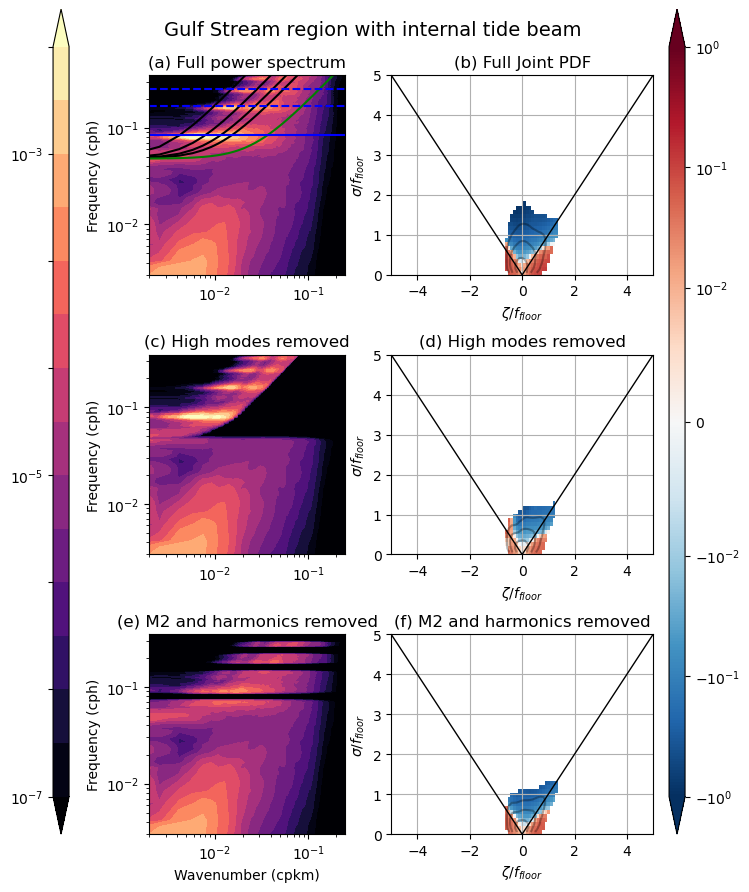

In [31]:
cmap = plt.get_cmap('seismic')
gs = GridSpec(3, 2, width_ratios=[1.5, 2], height_ratios=[1, 1, 1], hspace=0.4)

levels=np.arange(-1.5,1.501,0.05)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
fig = plt.figure(figsize=(8,11))
ax1 = fig.add_subplot(gs[0])

omega = power_unfilt.freq_time
kr =(power_unfilt.kr/2.22)
omega1 = (fm**2*(1+ (kr/1000/np.pi/2)**2/Kdia**2))**0.5*3600
lev_exp = np.linspace(-7,-2,16)
lev = np.power(10, lev_exp)[0:15]

cs = plt.contourf(kr,omega,np.abs(omega)*kr*power_unfilt.power_unfiltered,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)
plt.title('(a) Full power spectrum')
plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.35])
plt.ylabel('Frequency (cph)')

plt.plot(kr, omega1[:,1],'k')
plt.plot(kr, omega1[:,2],'k')
plt.plot(kr, omega1[:,3],'k')
plt.plot(kr, omega1[:,4],'k')
plt.plot(kr, omega1[:,10],'g')

plt.axhline(1/12,color='b')
plt.axhline(2/12,color='b',linestyle='--')
plt.axhline(3/12,color='b',linestyle='--')


ax2 = fig.add_subplot(gs[1])
cs1=h_DivPdf_eq.plot.pcolormesh(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_marginal_eq.plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.title('(b) Full Joint PDF')
ax2.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax2.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax2.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

ax3 = fig.add_subplot(gs[2])


cs = plt.contourf(kr,omega,np.abs(omega)*kr*power_filt.power_filtered,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)
plt.title('(c) High modes removed')
plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.35])
plt.ylabel('Frequency (cph)')


ax4 = fig.add_subplot(gs[3])
cs1=h_DivPdf_eq_filt.plot.pcolormesh(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_marginal_eq_filt.plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.title('(d) High modes removed')
ax4.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax4.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax4.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

ax5 = fig.add_subplot(gs[4])


cs = plt.contourf(kr,omega,np.abs(omega)*kr*power_fqfilt.power_fqfiltered,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)
plt.title('(e) M2 and harmonics removed')
plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.35])
plt.ylabel('Frequency (cph)')
plt.xlabel('Wavenumber (cpkm)')

ax4 = fig.add_subplot(gs[5])
cs1=h_DivPdf_eq_fqfilt.plot.pcolormesh(x='vort_bin', vmax=1, norm=mpl.colors.SymLogNorm(1e-2),add_colorbar=False)
h_marginal_eq_fqfilt.plot.contour(x='vort_bin',levels=[1e-2, 1e-3, 1e-4], colors='k', alpha=.3)
plt.title('(f) M2 and harmonics removed')
ax4.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
ax4.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
ax4.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')



cbar_ax = fig.add_axes([0.87, 0.11, 0.02, 0.75])
fig.colorbar(cs1, cax=cbar_ax,extend='both')

cbar_ax2 = fig.add_axes([0.1, 0.11, 0.02, 0.75])
fig.colorbar(cs, cax=cbar_ax2,extend='both')
cbar_ax2.yaxis.set_ticks_position('left')

fig.suptitle("Gulf Stream region with internal tide beam", fontsize=14, y=0.85)

plt.subplots_adjust(left=0.22, right=0.85,hspace=0.5,top=0.8)



fig.savefig('gs-freq-wn-filt-jpdf.png')

<>:8: SyntaxWarning: invalid escape sequence '\z'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\z'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_82/3528151781.py:8: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_82/3528151781.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')


Text(0, 0.5, '$\\sigma/f_{floor}$')

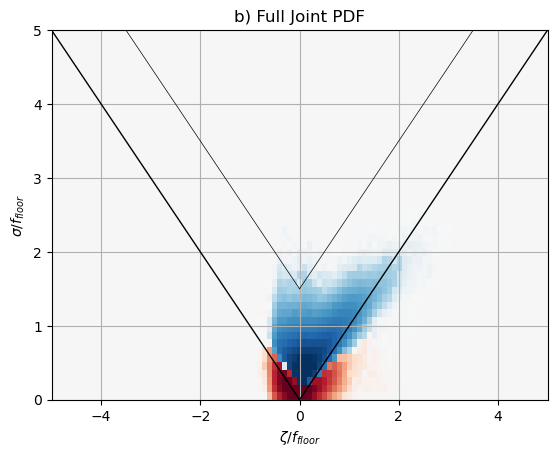

In [31]:
cs1=h_DivPdf_eq_fqfilt.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('b) Full Joint PDF')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

<>:8: SyntaxWarning: invalid escape sequence '\z'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\z'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_82/1396257229.py:8: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta/f_{floor}$')
/tmp/ipykernel_82/1396257229.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma/f_{floor}$')


Text(0, 0.5, '$\\sigma/f_{floor}$')

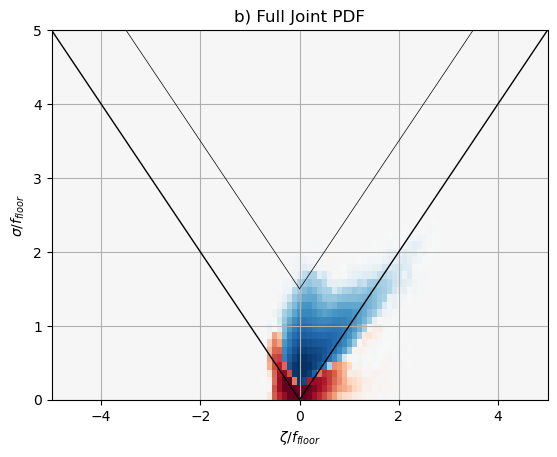

In [32]:
cs1=h_DivPdf_eq_filt.plot.pcolormesh(x='vort_bin', vmax=0.5, norm=mpl.colors.SymLogNorm(1e-3),add_colorbar=False)
plt.title('b) Full Joint PDF')
plt.plot(np.linspace(0,5), np.linspace(0,5),color='k',linewidth=1)
plt.plot(np.linspace(-5,0), np.linspace(5,0),color='k',linewidth=1)
plt.plot(np.linspace(0,3.5), np.linspace(1.5,5),color='k',linewidth=0.5)
plt.plot(np.linspace(-3.5,0), np.linspace(5,1.5),color='k',linewidth=0.5)
plt.grid()
plt.xlabel('$\zeta/f_{floor}$')
plt.ylabel('$\sigma/f_{floor}$')

In [43]:
with ProgressBar():
    u2_psa = xrft.power_spectrum(U_filtered.drop_vars('k').drop_vars('time').rename({"i_g": "i"}).load(), dim=['i','j','time'],window=True,window_correction=True).compute()
    v2_psa = xrft.power_spectrum(V_filtered.drop_vars('k').drop_vars('time').rename({"j_g": "j"}).load(), dim=['i','j','time'],window=True,window_correction=True).compute()
    #div_psa = xrft.power_spectrum(div_subset.load(), dim=['i','j','time'],window=True,window_correction=True).compute()
vel_psa = (u2_psa + v2_psa)*0.5

/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


In [44]:
def azimuthal_avg(k, l, f, N, nfactor):
    """
    Takes the azimuthal average of a given field.
    """
    k = k.values; l = l.values
    kk, ll = np.meshgrid(k, l)
    K = np.sqrt(kk**2 + ll**2)
    nbins = int(N/nfactor)
    if k.max() > l.max():
        ki = np.linspace(0., l.max(), nbins)
    else:
        ki = np.linspace(0., k.max(), nbins)

    kidx = np.digitize(np.ravel(K), ki)
    area = np.bincount(kidx)

    kr = np.bincount(kidx, weights=K.ravel()) / area

    if f.ndim == 2:
        iso_f = np.ma.masked_invalid(np.bincount(kidx,
                                    weights=f.data.ravel())
                                    / area) * kr
    else:
        raise ValueError('The data has too many or few dimensions. '
                        'The input should only have the two dimensions '
                        'to take the azimuthal averaging over.')

    return kr, iso_f

def iso_spec(ds):
    
    #Zlen = len(ds.Z)
    klen = len(ds.freq_i)
    omegalen = len(ds.freq_time)
    
    nfactor = 4. 
    ds_iso = np.zeros([omegalen ,  int(klen/nfactor+1)])

    for j in range(0,omegalen):
            kr, ds_iso[j,:] = azimuthal_avg(ds.freq_i, ds.freq_j, ds.isel(freq_time=j), 
                            len(ds.freq_i), nfactor)
    kr[0] = 0.
    ds_iso_xr = xr.DataArray(ds_iso, coords={'freq_time':ds.freq_time.values, 'kr':kr }, 
                             dims=['freq_time','kr'])
    
    return ds_iso_xr

In [45]:
ps_isoa = iso_spec(vel_psa)

/tmp/ipykernel_82/561257206.py:17: RuntimeWarning: invalid value encountered in divide
  kr = np.bincount(kidx, weights=K.ravel()) / area
/tmp/ipykernel_82/561257206.py:20: RuntimeWarning: invalid value encountered in divide
  iso_f = np.ma.masked_invalid(np.bincount(kidx,


/tmp/ipykernel_82/1215764662.py:7: UserWarning: Log scale: values of z <= 0 have been masked
  cs = plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both',levels=lev)


(0.003, 0.35)

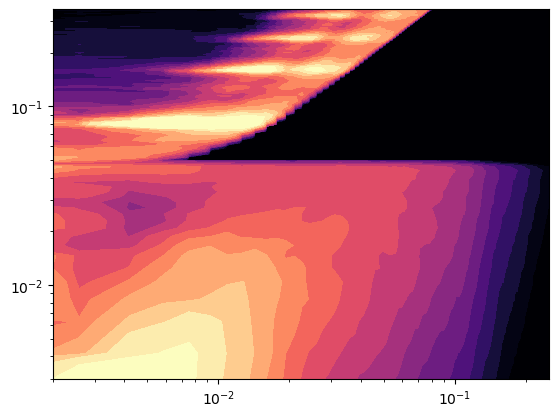

In [46]:
positive_ps = ps_isoa.isel(freq_time=slice(240,480))
omega = positive_ps.freq_time
kr =(positive_ps.kr/2.22)
lev_exp = np.linspace(-8,-3,16)
lev = np.power(10, lev_exp)[0:15]

cs = plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both',levels=lev)
#plt.colorbar(cs)



plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.003, 0.35])
#plt.xlabel('Wavenumber (cpkm)')
#plt.ylabel('Frequency (cph)')

In [49]:
#positive_ps.rename('power_unfiltered').to_dataset().to_netcdf('ps_unfiltered_gs.nc')
#positive_ps.rename('power_fqfiltered').to_dataset().to_netcdf('ps_fqfiltered_gs.nc')
positive_ps.rename('power_filtered').to_dataset().to_netcdf('ps_filtered_gs.nc')

In [48]:
kr

<xarray.DataArray 'kr' (kr: 136)> Size: 1kB
array([0.        , 0.00113298, 0.00258001, 0.00420839, 0.00584255,
       0.00753075, 0.00924816, 0.01091232, 0.01255709, 0.01425815,
       0.01594737, 0.0175974 , 0.01929044, 0.02097176, 0.02261851,
       0.02430822, 0.02599191, 0.02763683, 0.02932264, 0.03101043,
       0.03265919, 0.03433372, 0.03602624, 0.03770442, 0.03938593,
       0.04104558, 0.04269399, 0.04437876, 0.04605806, 0.04774645,
       0.04945249, 0.0511166 , 0.05275478, 0.05444263, 0.05612872,
       0.05781316, 0.05949252, 0.06114347, 0.06279874, 0.06448119,
       0.06616545, 0.06785613, 0.06952873, 0.07118934, 0.07286203,
       0.07452866, 0.0761894 , 0.07787238, 0.07956177, 0.08123598,
       0.08289119, 0.08455579, 0.08623414, 0.08792049, 0.08959541,
       0.09126863, 0.09294816, 0.09462018, 0.09629828, 0.09797895,
       0.0996621 , 0.10134422, 0.1030066 , 0.10465869, 0.10634293,
       0.10803133, 0.10969848, 0.11137897, 0.11305527, 0.11471483,
       0.11638862, 0.11806822, 0.11974438, 0.12143062, 0.12310057,
       0.12474488, 0.12642159, 0.12812081, 0.12980053, 0.13145923,
       0.13312999, 0.13480131, 0.13647213, 0.13814796, 0.13983053,
       0.14150935, 0.14318029, 0.14485679, 0.14652938, 0.14819297,
       0.14986577, 0.15154796, 0.15321908, 0.15489323, 0.15657253,
       0.15824707, 0.1599166 , 0.16158019, 0.16326475, 0.16495215,
       0.16661382, 0.16827743, 0.16995983, 0.17163709, 0.17330795,
       0.17498581, 0.17665107, 0.17832658, 0.18000627, 0.18167193,
       0.18335681, 0.18504421, 0.18669955, 0.18836917, 0.19005784,
       0.19173785, 0.19341714, 0.19508612, 0.19673926, 0.19841469,
       0.20010218, 0.20178019, 0.20345293, 0.20513118, 0.2068023 ,
       0.20846963, 0.21013703, 0.21181298, 0.21349381, 0.2151702 ,
       0.2168439 , 0.21851241, 0.22017918, 0.22185876, 0.22353605,
       0.2527837 ])
Coordinates:
  * kr       (kr) float64 1kB 0.0 0.002515 0.005728 ... 0.4925 0.4963 0.5612

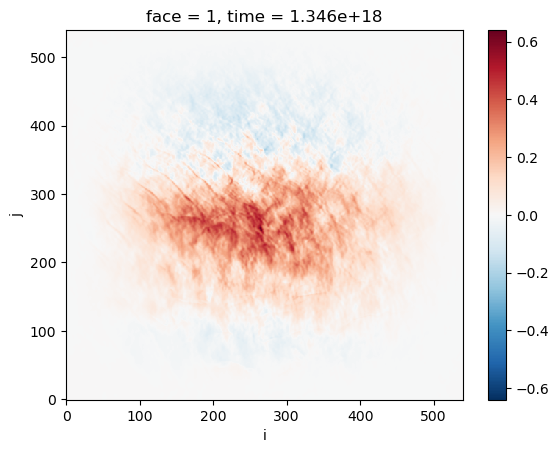

In [42]:
np.real(U_filtered.drop_vars('i').drop_vars('j')).isel(time=240).plot()

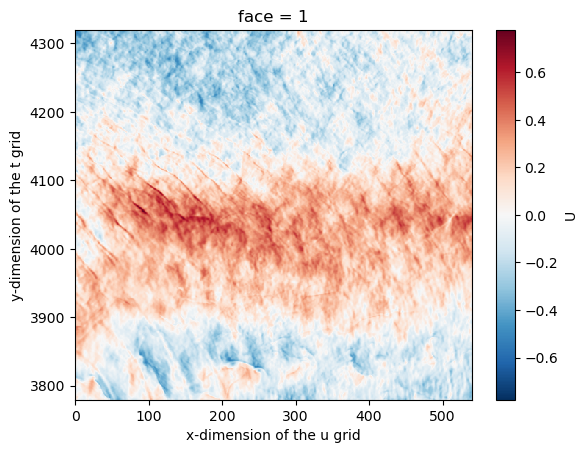

In [41]:
np.real(u_subset.drop_vars('time')).isel(time=240).plot()

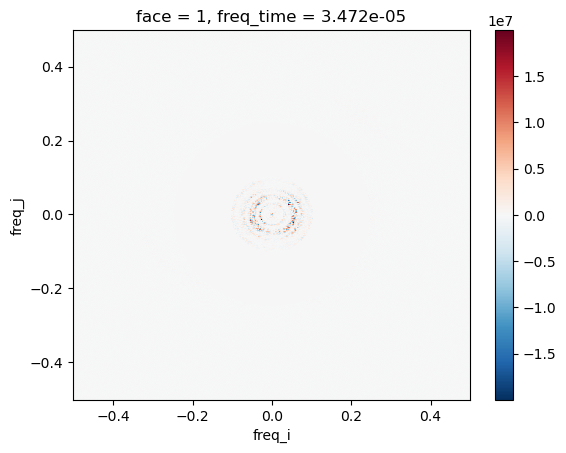

In [24]:
np.real(wnfiltered_U).isel(freq_time=400).plot()